### ***ML LAB-2***
#### Name: Yashmi Patle
#### Section: A
#### Batch: A1
#### Roll no.: 15

### **AIM: To develop a Linear Regression model for predicting house prices using suitable dataset.**

#### **Materials Required**

- Python 3.x
- Jupyter Notebook / Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- House Price Dataset (USA_Housing.csv)

#### **Procedure**

1. Import the required Python libraries.
2. Load the House Price dataset.
3. Perform data preprocessing and visualization.
4. Select the input and output variables.
5. Split the dataset into training and testing sets.
6. Train the Simple Linear Regression model.
7. Predict house prices using the test data.
8. Evaluate the model using MAE, MSE, RMSE, and R² Score.
9. Apply Hyperparameter Tuning using GridSearchCV.
10. Select the best model and evaluate its performance.
11. Display the regression graph.
12. Predict the house price for a new input value.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#### Description:
#### The required Python libraries were imported successfully. These libraries are used for data processing, visualization, model training, and evaluation.


In [ ]:
df=pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


##### Description:
##### The dataset was loaded successfully using Pandas. The `head()` function displays the first five records to verify that the data has been imported correctly.


In [ ]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


#### Description:
#### The describe() function displays the statistical summary of the dataset. It shows values like count, mean, minimum, maximum, and standard deviation for each numerical column.

In [ ]:
df.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


####  Description:
#### The `isnull().sum()` function checks for missing values in the dataset. The output shows that all columns have **0 missing values**, indicating the dataset is complete and ready for model training.


In [ ]:
df.duplicated().sum()

np.int64(0)

#### Description:
#### The `duplicated().sum()` function checks for duplicate records in the dataset. The output **0** indicates that no duplicate values are present in the dataset.


In [ ]:
if 'Address' in df.columns:
  df.drop(['Address'],axis=1,inplace=True)

#### Description:
#### This code removes the **Address** column from the dataset. Since it is a text column and not required for prediction, it is dropped before training the Linear Regression model.


In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


#### Description:
#### The `head()` function displays the updated dataset after removing the **Address** column. It confirms that only the relevant numerical features remain for training the Linear Regression model.


In [ ]:
pd.set_option('display.float_format','{:.2f}'.format)

#### Description:
#### This code sets the display format for floating-point numbers to **2 decimal places**. It makes the dataset output easier to read and understand.


In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


#### Description:
#### The dataset is displayed with values rounded to **2 decimal places**. This improves readability while keeping the data ready for further analysis and model training.


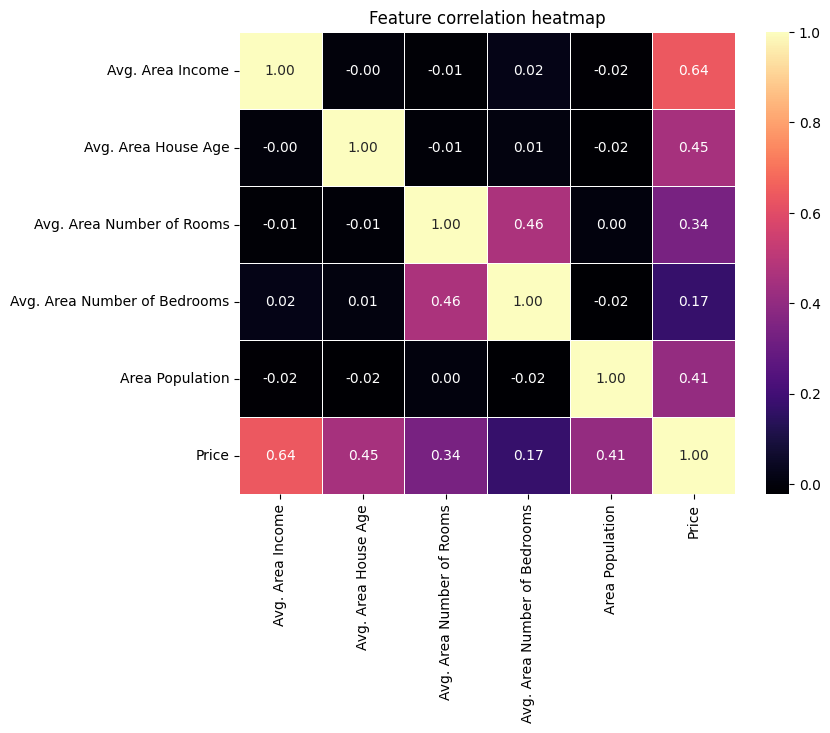

In [ ]:
plt.figure(figsize=(8,6))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,cmap='magma',annot=True,fmt=".2f",linewidth=0.5)
plt.title("Feature correlation heatmap")
plt.show()

#### Description:
#### The heatmap shows the correlation between the dataset features. It helps identify how strongly each feature is related to the house price and other variables.


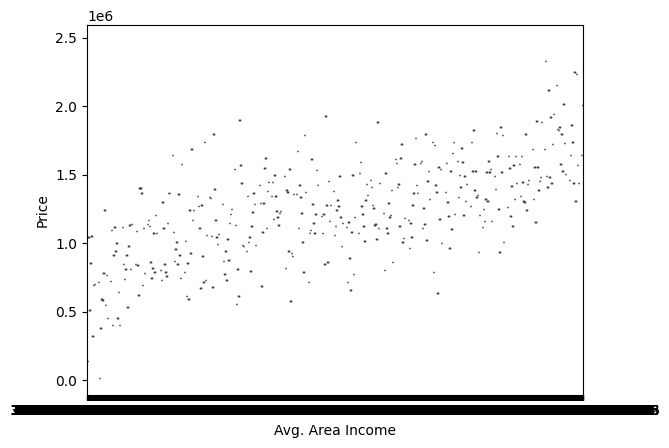

In [ ]:
sns.boxplot(x=df["Avg. Area Income"],y=df["Price"])
plt.show()

#### Description:
#### The box plot shows the relationship between Average Area Income and House Price. It helps visualize the data distribution and identify any outliers.

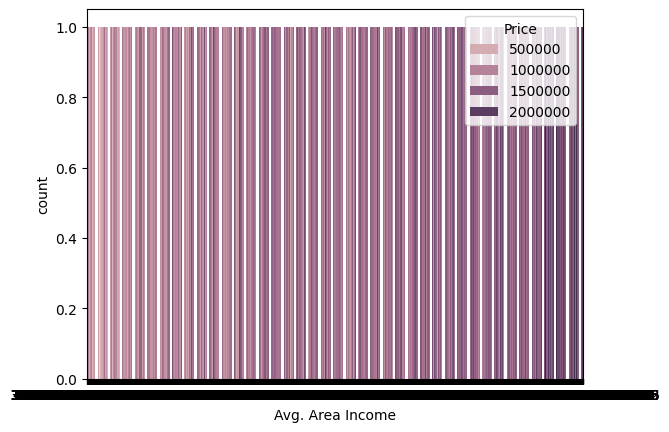

In [ ]:
sns.countplot(x="Avg. Area Income",hue="Price", data=df)
plt.show()

#### Description:
#### The count plot visualizes the distribution of Average Area Income with respect to House Price. It helps compare the frequency of data points across different income levels.

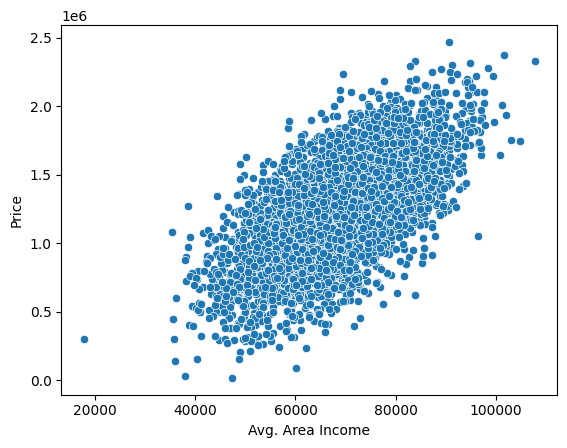

In [ ]:
sns.scatterplot(x="Avg. Area Income",y="Price",data=df)
plt.show()

#### Description:
#### The scatter plot shows the relationship between Average Area Income and House Price. It helps visualize the correlation and trend between these two variables.

###**Simple Linear Regression (SLR)**
#### Simple Linear Regression (SLR) is used to predict the value of one dependent variable based on a single independent variable. It finds the best-fit line to model the relationship between the two variables.

In [ ]:
x=df[['Avg. Area Income']]
y=df['Price']

#### Description:
#### The independent variable (X) is selected as Average Area Income, and the dependent variable (Y) is selected as House Price. These variables are used to train the Simple Linear Regression model.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#### Description:
#### The dataset is divided into training and testing sets using the train_test_split() function. Here, 80% of the data is used for training and 20% for testing the model.

In [ ]:
from sklearn.linear_model import LinearRegression
slr_model=LinearRegression()
slr_model.fit(x_train,y_train)

LinearRegression()

#### Description:
#### The Linear Regression model is created and trained using the training dataset. The fit() function learns the relationship between Average Area Income and House Price.

In [ ]:
y_pred=slr_model.predict(x_test)

#### Description:
#### The trained Linear Regression model predicts house prices using the test dataset. The predicted values are stored in the variable y_pred for evaluation.

In [ ]:
from sklearn.metrics import  mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
print("Simple Linear Regression Results")
print("--------------------------------")
print("MAE :",mean_absolute_error(y_test,y_pred))
print("MSE :",mean_squared_error(y_test,y_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score :",r2_score(y_test,y_pred))

Simple Linear Regression Results
--------------------------------
MAE : 216826.35309989064
MSE : 74194887058.66
RMSE : 272387.38417676394
R2 Score : 0.39694865192619766


#### Description:
#### The model's performance is evaluated using MAE, MSE, RMSE, and R² Score. These metrics measure the prediction error and overall accuracy of the Simple Linear Regression model.

In [ ]:
print("Intercept :",slr_model.intercept_)
print("Slope :",slr_model.coef_[0])

Intercept : -225053.70287170145
Slope : 21.208906292657513


#### Description:
#### The intercept and slope of the trained Linear Regression model are displayed. These values define the regression equation used to predict house prices.

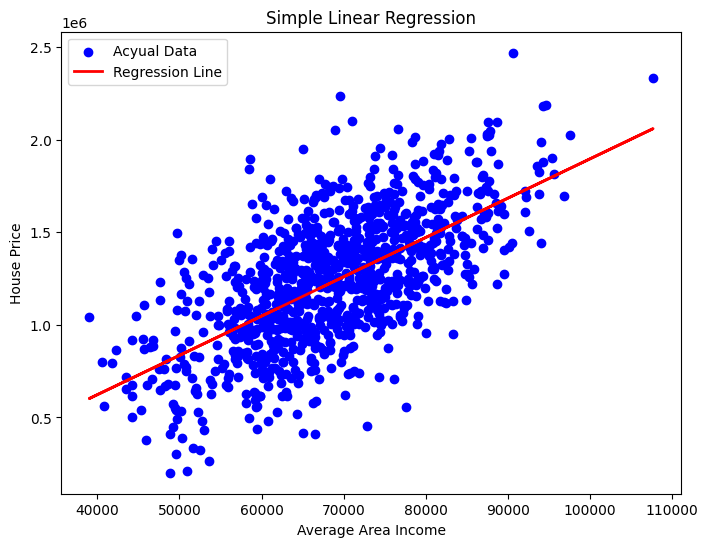

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_test,y_test,color='blue',label='Acyual Data')
plt.plot(x_test,y_pred,color='red',linewidth=2,label='Regression Line')
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

#### Description:
#### The scatter plot displays the actual house prices and the regression line predicted by the Simple Linear Regression model. It helps visualize how well the model fits the test data.

In [ ]:
income=float(input("Enter Avg. Area Income: "))
new_data=np.array([[income]])
prediction=slr_model.predict(new_data)
print("Prediction House Price=${:,.2f}".format(prediction[0]))

Enter Avg. Area Income: 80000
Prediction House Price=$1,471,658.80


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Description:
#### The trained Simple Linear Regression model predicts the house price based on the user-entered Average Area Income. The predicted house price is displayed as the final output.

###**Hyperparameter Tunning**
#### Hyperparameter Tuning is the process of selecting the best model parameters to improve prediction accuracy. It helps optimize the performance of the machine learning model by finding the most suitable parameter values.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

#### Description:
#### The required libraries are imported for building and tuning the Linear Regression model. GridSearchCV is used for hyperparameter tuning, while the evaluation metrics measure the model's performance.

In [ ]:
lr=LinearRegression()

#### Description:
#### A Linear Regression model object is created and stored in the variable `lr`. This model will be used for hyperparameter tuning and training.

In [ ]:
lr_params={
    'fit_intercept':[True,False],
    'positive':[True,False]
}

#### Description:
#### A dictionary of hyperparameters is created for the Linear Regression model. The fit_intercept and positive parameters are tested with different values to find the best-performing model using GridSearchCV.

In [ ]:
grid_search=GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

#### Description:
#### GridSearchCV is configured to perform hyperparameter tuning on the Linear Regression model. It uses 5-fold cross-validation and the R² score to identify the best combination of parameters.

In [ ]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

#### Description:
#### The GridSearchCV model is trained using the training dataset. It evaluates different combinations of hyperparameters and selects the best-performing model based on the R² score.

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'fit_intercept': True, 'positive': True}


#### Description:
#### The best hyperparameter values selected by GridSearchCV are displayed. These parameters provide the highest R² score and improve the performance of the Linear Regression model.

In [ ]:
{'fit_intercept':True,
 'positive':False}

{'fit_intercept': True, 'positive': False}

#### Description:
#### The output shows the best hyperparameter combination selected by GridSearchCV. Here, fit_intercept=True and positive=False provide the best model performance based on the R² score.

In [ ]:
print("Best Cross Validatyion Score:")
print(grid_search.best_score_)

Best Cross Validatyion Score:
0.4111086193361001


#### Description:
#### The best cross-validation R² score obtained during hyperparameter tuning is displayed. This score indicates how well the optimized Linear Regression model is expected to perform on unseen data.

In [ ]:
best_model=grid_search.best_estimator_

#### Description:
#### The best-performing Linear Regression model selected by GridSearchCV is stored in the variable `best_model`. This optimized model is used for making predictions and evaluating performance.

In [ ]:
LinearRegression(
    fit_intercept=True,
    positive=False
)

LinearRegression()

#### Description:
#### The output displays the optimized Linear Regression model with the best hyperparameter values. The model uses fit_intercept=True and positive=False for improved prediction performance.

In [ ]:
y_pred=best_model.predict(x_test)

#### Description:
#### The optimized Linear Regression model predicts house prices using the test dataset. The predicted values are stored in the variable `y_pred` for evaluating the model's performance.

In [ ]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 SCORE:",r2)

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2 SCORE: 0.39694865192619766


#### Description:
#### The optimized Linear Regression model is evaluated using MAE, MSE, RMSE, and R² Score. These metrics indicate the prediction error and overall accuracy of the tuned model on the test dataset.

In [ ]:
print(best_model)

LinearRegression(positive=True)


#### Description:
#### The optimized Linear Regression model is displayed with the best hyperparameter settings selected by GridSearchCV. This confirms the final model configuration used for prediction.

In [ ]:
income=float(input("Enter Average Area Income:"))
house_age=float(input("Enter Average Area House Age:"))
rooms=float(input("Enter Average Area Number of Rooms:"))
bedrooms=float(input("Enter Average Area Number of Bedrooms:"))
population=float(input("Enter Area Population:"))
test_input=np.array([[income, house_age, rooms, bedrooms, population]])
predicted_price=slr_model.predict(test_input)
print("\nPredicted House Price: ${:,.2f}".format(predicted_price[0])

### **Ridge Regression**

In [ ]:
from sklearn.model_selection import GridSearchCV

#### Description:
#### The `GridSearchCV` class is imported from the `sklearn.model_selection` module to perform hyperparameter tuning. It systematically evaluates different combinations of parameters using cross-validation and identifies the best-performing model.

In [ ]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(x_train,y_train)
ridge_pred=ridge.predict(x_test)
print("Default Ridge R2:",r2_score(y_test,ridge_pred))

Default Ridge R2: 0.3969486519262033


#### Description:
#### The Ridge Regression model is created, trained on the training dataset, and used to predict house prices for the test dataset. The predicted values are stored in the variable `ridge_pred`, and the model's performance is evaluated using the R² score.

In [ ]:
param_grid={'alpha':[0.001,0.01,0.1,1,10,100]}

#### Description:
#### The parameter grid is defined with different values of the regularization parameter `alpha`. These values are used by `GridSearchCV` to identify the optimal hyperparameter for the Ridge Regression model.

In [ ]:
grid_ridge=GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring='r2',cv=5)

#### Description:
#### The `GridSearchCV` object is created for the Ridge Regression model using the specified parameter grid. It evaluates different `alpha` values with 5-fold cross-validation and selects the model that achieves the highest R² score.

In [ ]:
grid_ridge.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

#### Description:
#### The `GridSearchCV` object is trained on the training dataset to evaluate different values of the `alpha` parameter. It identifies the best-performing Ridge Regression model based on cross-validation.

In [ ]:
print("Best Alpha:",grid_ridge.best_params_)

Best Alpha: {'alpha': 100}


#### Description:
#### The best value of the `alpha` parameter selected by `GridSearchCV` is displayed. This optimal parameter is chosen based on the highest cross-validation R² score.

In [ ]:
print(grid_ridge.best_score_)

0.41110861933657433


#### Description:
#### The best cross-validation R² score achieved by the optimized Ridge Regression model is displayed. This score represents the model's performance using the optimal value of the `alpha` parameter.

In [ ]:
best_ridge=grid_ridge.best_estimator_
ridge_pred=best_ridge.predict(x_test)

#### Description:
#### The best Ridge Regression model selected by `GridSearchCV` is stored in the variable `best_ridge`. This optimized model predicts house prices for the test dataset, and the predicted values are stored in `ridge_pred`.

In [ ]:
print("MAE :",mean_absolute_error(y_test,ridge_pred))
print("MSE :",mean_squared_error(y_test,ridge_pred))
print("RMSE :",np.sqrt(mean_absolute_error(y_test,ridge_pred)))
print("R2 :",r2_score(y_test,ridge_pred))

MAE : 216826.35310007748
MSE : 74194887058.58911
RMSE : 465.646167277341
R2 : 0.39694865192677387


#### Description:
#### The performance of the optimized Ridge Regression model is evaluated using the MAE, MSE, RMSE, and R² metrics. These evaluation measures assess the prediction error and the overall accuracy of the model on the test dataset.

### **Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso
param_grid={'alpha':[0.001,0.01,0.1,1,10]}

#### Description:
#### The `Lasso` Regression model is imported, and a parameter grid containing different values of the regularization parameter `alpha` is defined. These values are used for hyperparameter tuning to identify the optimal Lasso Regression model.

In [ ]:
grid_lasso=GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')
grid_lasso.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

#### Description:
#### The `GridSearchCV` object is created for the Lasso Regression model using the specified parameter grid and trained on the training dataset. It evaluates different `alpha` values with 5-fold cross-validation and selects the best-performing model based on the R² score.

In [ ]:
print(grid_lasso.best_params_)

{'alpha': 10}


#### Description:
#### The best value of the `alpha` parameter selected by `GridSearchCV` for the Lasso Regression model is displayed. This optimal parameter is chosen based on the highest cross-validation R² score.

In [ ]:
lasso_pred=grid_lasso.predict(x_test)
print(r2_score(y_test,lasso_pred))

0.39694865193706386


#### Description:
#### The optimized Lasso Regression model predicts house prices using the test dataset. The predicted values are stored in `lasso_pred`, and the model's performance is evaluated using the R² score.

In [ ]:
predictions=slr_model.predict(x_test)

#### Description:
#### The trained Simple Linear Regression model predicts house prices using the test dataset. The predicted values are stored in the variable `predictions` for evaluating the model's performance.

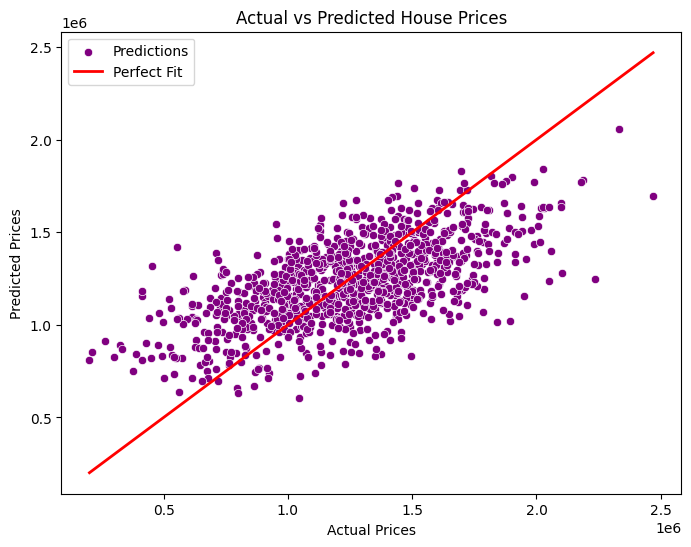

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=predictions,color='purple',label='Predictions')
# Add a reference line (perfect prediction line)
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red',linewidth=2,label='Perfect Fit')
# Add labels and legend
plt.title("Actual vs Predicted House Prices")
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

#### Description:
#### A scatter plot is created to compare the actual and predicted house prices generated by the Simple Linear Regression model. A reference line representing perfect predictions is added to visually evaluate the model's prediction accuracy.

# **Github Link:**
https://github.com/yashmi-patle08/Machine-Learning-Practicals/blob/main/Linear%20Regression.ipynb

# **Viva Questions**

### Q1. What is Linear Regression?

**Answer:**
Linear Regression is a supervised machine learning algorithm used to predict continuous values based on input features.

### Q2. What is the dependent variable in this project?

**Answer:**
The dependent variable is **House Price**, which is predicted using the Average Area Income.

### Q3. What is the R² Score?

**Answer:**
The R² Score measures how well the regression model fits the data. A higher value indicates better model performance.

### Q4. Why is train_test_split() used?

**Answer:**
It divides the dataset into training and testing sets so the model can be trained and evaluated on different data.

### Q5. Which Python library provides the Linear Regression algorithm?

**Answer:**
The **Scikit-learn (sklearn)** library provides the `LinearRegression` class for building regression models.